In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(
    rc={"patch.force_edgecolor": True, "patch.edgecolor": "black", "font": "Palatino"}
)
sns.set_style("ticks")

plt.rcParams["font.family"] = "Palatino"  # change to palatino
plt.rcParams["font.size"] = 10  # change to palatino

In [2]:
langs = ["de", "fr", "pt", "nl", "ko"]

In [3]:
dfs = []
for lang in langs:
    path = f"paper_results/test.en-{lang}.csv"
    df = pd.read_csv(path)
    dfs.append(df)
df = pd.concat(dfs)
df.columns

Index(['source_language', 'target_language', 'source', 'reference', 'doc_id',
       'client_id', 'sender', 'tags', 'lp', 'baseline', 'baseline-comet',
       'greedy-7b-w-context', 'greedy-7b-w-context-comet',
       'greedy-7b-wo-context', 'greedy-7b-wo-context-comet',
       'greedy-7b-5shot-w-context', 'greedy-7b-5shot-w-context-comet',
       'greedy-7b-5shot-wo-context', 'greedy-7b-5shot-wo-context-comet',
       'greedy-7b-ft-w-context', 'greedy-7b-ft-w-context-comet',
       'greedy-7b-ft-wo-context', 'greedy-7b-ft-wo-context-comet', 'mbr',
       'mbr-comet', 'mbr-source', 'mbr-source-comet', 'mbr-hyp',
       'mbr-hyp-comet', 'greedy-70b-5shot-w-context',
       'greedy-70b-5shot-w-context-comet', 'greedy-70b-5shot-wo-context',
       'greedy-70b-5shot-wo-context-comet', 'baseline-context-comet-qe',
       'greedy-7b-w-context-context-comet-qe',
       'greedy-7b-wo-context-context-comet-qe',
       'greedy-7b-5shot-w-context-context-comet-qe',
       'greedy-7b-5shot-wo-cont

In [4]:
model = "greedy-7b"
df["context_helps"] = df.apply(
    lambda x: (
        1
        if x[f"{model}-w-context-comet"] > x[f"{model}-wo-context-comet"]
        else 0 if x[f"{model}-w-context-comet"] < x[f"{model}-wo-context-comet"] else -1
    ),
    axis=1,
)
# break df in the comet bins: [0, 0.3], [0.3, 0.4], [0.4, 0.5], [0.5, 0.6], [0.6, 0.7], [0.7, 0.8], [0.8, 0.9], [0.9, 1]
df["comet_bin"] = pd.cut(
    df[f"{model}-wo-context-comet"],
    bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[
        "[0, 0.5]",
        "[0.5, 0.6]",
        "[0.6, 0.7]",
        "[0.7, 0.8]",
        "[0.8, 0.9]",
        "[0.9, 1]",
    ],
)
print(df["comet_bin"].value_counts())
df.groupby(by="lp")["context_helps"].value_counts(normalize=True)

comet_bin
[0.9, 1]      7353
[0.8, 0.9]    2128
[0.7, 0.8]     470
[0.6, 0.7]     147
[0.5, 0.6]      59
[0, 0.5]        12
Name: count, dtype: int64


lp        context_helps
de-en     -1               0.360558
           0               0.359562
           1               0.279880
en-de      0               0.343298
          -1               0.330762
           1               0.325940
en-fr      0               0.357746
          -1               0.334272
           1               0.307981
en-ko      0               0.446504
           1               0.363100
          -1               0.190396
en-nl      1               0.425071
           0               0.332705
          -1               0.242224
en-pt-br   0               0.382583
          -1               0.318004
           1               0.299413
fr-en      0               0.364522
          -1               0.357700
           1               0.277778
ko-en     -1               0.386164
           0               0.376101
           1               0.237736
nl-en     -1               0.356394
           0               0.355346
           1               0.288260
pt-b

# Disregarding ties

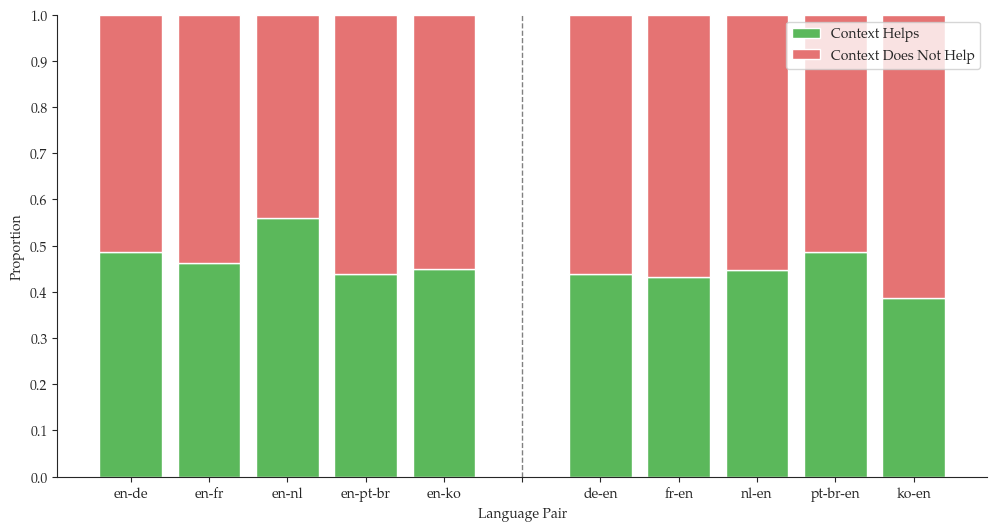

In [5]:
# Assuming df is your DataFrame
plot_df = df[df["context_helps"].isin([0, 1])]

# Manually order the language pairs as specified
order = [
    "en-de",
    "en-fr",
    "en-nl",
    "en-pt-br",
    "en-ko",
    "",
    "de-en",
    "fr-en",
    "nl-en",
    "pt-br-en",
    "ko-en",
]

# Pivot the data to get the counts of context_helps (0 and 1) for each language pair
pivot_df = plot_df.pivot_table(
    index="lp", columns="context_helps", aggfunc="size", fill_value=0
)

# Add a gap (empty row) between en-xx and xx-en groups
pivot_df.loc[""] = [0, 0]  # Adding an empty row as a gap
pivot_df = pivot_df.reindex(
    order
)  # Reorder the DataFrame according to the specified order

# Normalize the counts to get proportions
pivot_df_normalized = pivot_df.div(pivot_df.sum(axis=1), axis=0).fillna(0)

# Custom colors that go well with the specified blue
green_shade = "#5BB85B"  # A soft green
red_shade = "#E57373"  # A soft red

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Bottom bar: context helps (1)
ax.bar(
    pivot_df_normalized.index,
    pivot_df_normalized[1],
    color=green_shade,
    label="Context Helps",
)

# Top bar: context does not help (0), stacked on top of the green bar
ax.bar(
    pivot_df_normalized.index,
    pivot_df_normalized[0],
    bottom=pivot_df_normalized[1],
    color=red_shade,
    label="Context Does Not Help",
)

# Customize the appearance
ax.set_xlabel("Language Pair")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

# Set x-ticks and labels
ax.set_xticks(range(len(pivot_df_normalized.index)))
ax.set_xticklabels(pivot_df_normalized.index, rotation=0, ha="center")

# Remove the label for the gap
ax.set_xticklabels(
    [label if label != "" else "" for label in pivot_df_normalized.index]
)

# Add a vertical line to indicate the separation between en-xx and xx-en
ax.axvline(x=5, color="gray", linestyle="--", lw=1)

# Add legend
ax.legend()

# Despining
sns.despine(ax=ax, right=True, left=False)

plt.show()

/mnt/data/jpombal/tmp/ipykernel_1637216/1029370490.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  en_xx_counts = en_xx_df.groupby("comet_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/1029370490.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  en_xx_means = en_xx_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1637216/1029370490.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

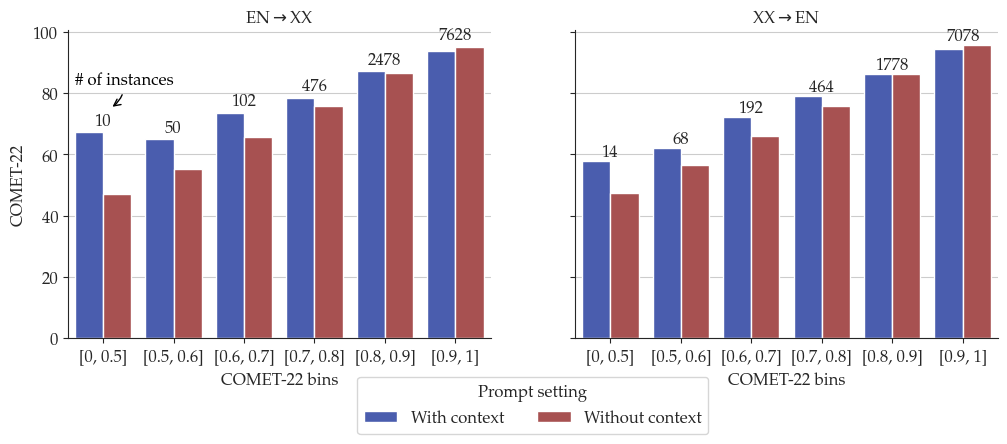

In [6]:
plot_df = df.copy()

# Split the DataFrame into two: one for en-xx and one for xx-en language pairs
en_xx_df = plot_df[plot_df["lp"].str.startswith("en-")]
xx_en_df = plot_df[plot_df["lp"].str.endswith("-en")]

# Convert both DataFrames into long format
en_xx_df = pd.melt(
    en_xx_df,
    id_vars=["lp", "comet_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
en_xx_df["comet"] = 100 * en_xx_df["comet"]

xx_en_df = pd.melt(
    xx_en_df,
    id_vars=["lp", "comet_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
xx_en_df["comet"] = 100 * xx_en_df["comet"]

# Manually order the COMET-22 bins
order = [
    "[0, 0.5]",
    "[0.5, 0.6]",
    "[0.6, 0.7]",
    "[0.7, 0.8]",
    "[0.8, 0.9]",
    "[0.9, 1]",
]

cmap = sns.color_palette(["#3953BF", "#b54343"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Plot for en-xx language pairs
sns.barplot(
    ax=ax1,
    data=en_xx_df,
    x="comet_bin",
    y="comet",
    hue="model",
    errorbar=None,
    hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
    palette=cmap,
    legend=False,
    order=order,
)

ax1.annotate(
    "# of instances",
    xy=(0.1, 75),  # point to which the arrow will point
    xytext=(-0.4, 83),  # position of the text
    arrowprops=dict(
        arrowstyle="->", color="black", connectionstyle="arc3,rad=-0.3"  # arrow style
    ),
    fontsize=12,
    color="black",
    ha="left",
)

# ax1.annotate(
#     "Quality improvement\nfrom adding context.",
#     xy=(0, 0.735),  # point to which the arrow will point
#     xytext=(0.3, 0.7),  # position of the text
#     fontsize=10,
#     color="black",
#     ha="left",
# )
# ax1.annotate(
#     "",
#     xy=(0.05, 0.67),  # point to which the arrow will point
#     xytext=(0.3, 0.26),  # position of the text
#     arrowprops=dict(
#         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.1"  # arrow style
#     ),
#     fontsize=10,
#     color="black",
#     ha="left",
# )

# Calculate counts and mean heights for en-xx
en_xx_counts = en_xx_df.groupby("comet_bin").size()
en_xx_means = en_xx_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()

# Add counts to the en-xx plot
for i, bin_label in enumerate(order):
    if bin_label in en_xx_counts.index:
        count = en_xx_counts[bin_label]
        max_mean_height = en_xx_means.loc[bin_label].max()
        ax1.text(
            i,
            max_mean_height + 0.01 * max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=12,
        )

# Plot for xx-en language pairs
sns.barplot(
    ax=ax2,
    data=xx_en_df,
    x="comet_bin",
    y="comet",
    hue="model",
    errorbar=None,
    hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
    palette=cmap,
    order=order,
)

# Calculate counts and mean heights for xx-en
xx_en_counts = xx_en_df.groupby("comet_bin").size()
xx_en_means = xx_en_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()

# Add counts to the xx-en plot
for i, bin_label in enumerate(order):
    if bin_label in xx_en_counts.index:
        count = xx_en_counts[bin_label]
        max_mean_height = xx_en_means.loc[bin_label].max()
        ax2.text(
            i,
            max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=12,
        )

# Set x-tick labels and axis labels
ax1.set_xticklabels(order)
ax1.set_title(r"EN$\rightarrow$XX", fontsize=12)
ax1.set_xlabel("COMET-22 bins", fontsize=12)
ax1.set_ylabel("COMET-22", fontsize=12)
ax1.tick_params(axis="both", which="major", labelsize=12)

ax2.set_xticklabels(order)
ax2.set_title(r"XX$\rightarrow$EN", fontsize=12)
ax2.set_xlabel("COMET-22 bins", fontsize=12)
ax2.set_ylabel("")
ax2.tick_params(axis="both", which="major", labelsize=12)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(-0.1, -0.1),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# Despining both axes
sns.despine(ax=ax1, right=True, left=False)
sns.despine(ax=ax2, right=True, left=False)
ax1.grid(axis="y")
ax2.grid(axis="y")
# plt.savefig("plots/comet_bins_context.pdf", bbox_inches="tight")
plt.show()

# agg lps

/mnt/data/jpombal/tmp/ipykernel_1637216/891389442.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_counts = plot_df.groupby("comet_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/891389442.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1637216/891389442.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order)


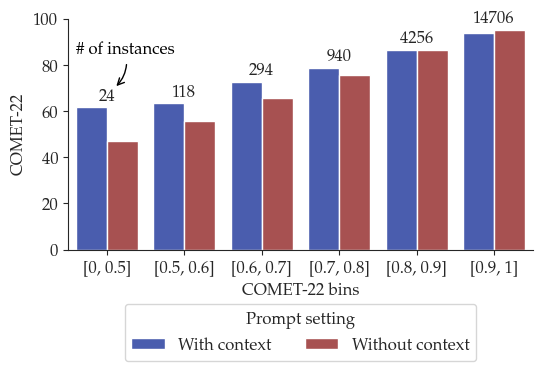

In [7]:
plot_df = df.copy()

# Convert both DataFrames into long format
plot_df = pd.melt(
    plot_df,
    id_vars=["lp", "comet_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
plot_df["comet"] = 100 * plot_df["comet"]

# Manually order the COMET-22 bins
order = [
    "[0, 0.5]",
    "[0.5, 0.6]",
    "[0.6, 0.7]",
    "[0.7, 0.8]",
    "[0.8, 0.9]",
    "[0.9, 1]",
]

cmap = sns.color_palette(["#3953BF", "#b54343"])

fig, ax = plt.subplots(figsize=(6, 3))

# Plot for en-xx language pairs
sns.barplot(
    ax=ax,
    data=plot_df,
    x="comet_bin",
    y="comet",
    hue="model",
    errorbar=None,
    hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
    palette=cmap,
    order=order,
)

ax.annotate(
    "# of instances",
    xy=(0.1, 70),  # point to which the arrow will point
    xytext=(-0.4, 85),  # position of the text
    arrowprops=dict(
        arrowstyle="->", color="black", connectionstyle="arc3,rad=-0.3"  # arrow style
    ),
    fontsize=12,
    color="black",
    ha="left",
)

# Calculate counts and mean heights for en-xx
plot_df_counts = plot_df.groupby("comet_bin").size()
plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()

# Add counts to the en-xx plot
for i, bin_label in enumerate(order):
    if bin_label in plot_df_counts.index:
        count = plot_df_counts[bin_label]
        max_mean_height = plot_df_means.loc[bin_label].max()
        ax.text(
            i,
            max_mean_height + 0.01 * max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=12,
        )

# Set x-tick labels and axis labels
ax.set_xticklabels(order)
ax.set_xlabel("COMET-22 bins", fontsize=12)
ax.set_ylabel("COMET-22", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.2),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# Despining both axes
sns.despine(ax=ax, right=True, left=False)
# ax.grid(axis="y")
# plt.savefig("plots/comet_bins_context_agg.pdf", bbox_inches="tight")
plt.show()

# by lps

##### en-xx

/mnt/data/jpombal/tmp/ipykernel_1637216/1248369739.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_counts = plot_df.groupby("comet_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/1248369739.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1637216/1248369739.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order)
/mnt/data/jpombal/tmp/ipykernel_1637216/1248369739.py:47: F

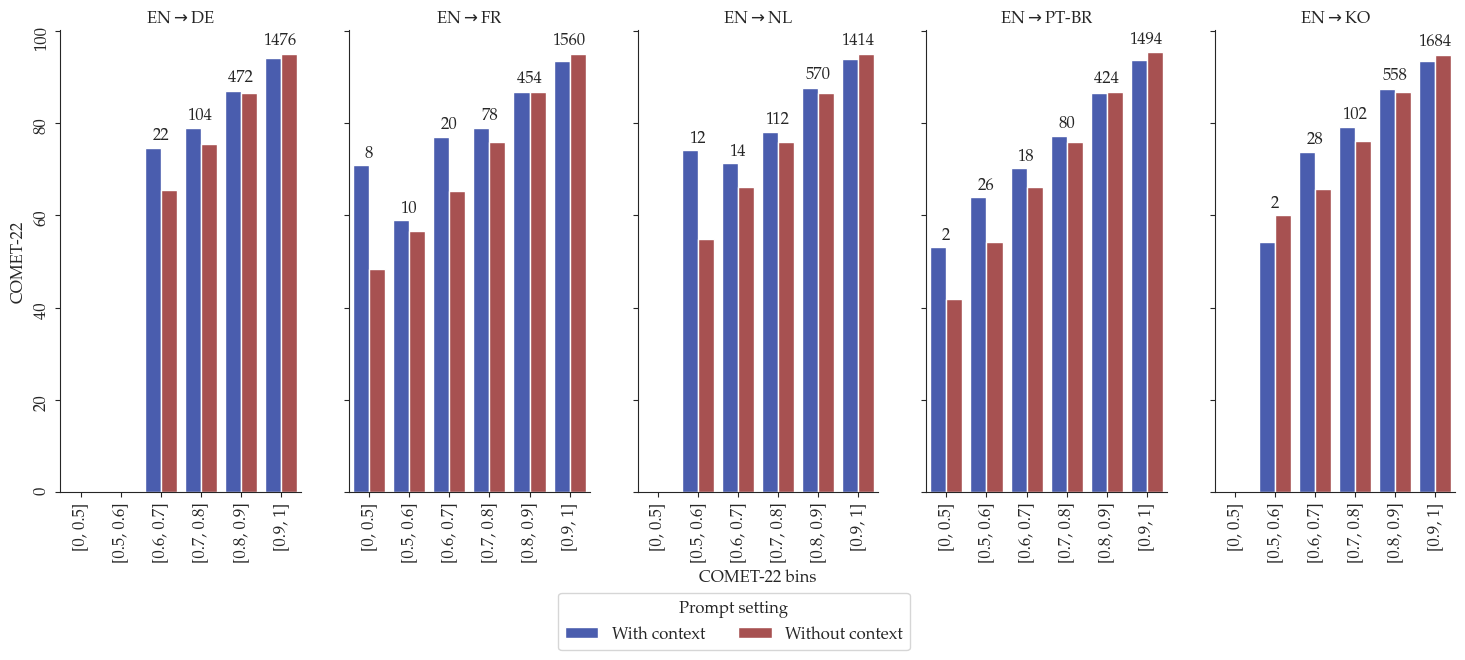

In [8]:
plot_df = df.copy()

# Manually order the COMET-22 bins
order = [
    "[0, 0.5]",
    "[0.5, 0.6]",
    "[0.6, 0.7]",
    "[0.7, 0.8]",
    "[0.8, 0.9]",
    "[0.9, 1]",
]

# Convert both DataFrames into long format
full_plot_df = pd.melt(
    plot_df,
    id_vars=["lp", "comet_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
full_plot_df["comet"] = 100 * full_plot_df["comet"]

cmap = sns.color_palette(["#3953BF", "#b54343"])

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for lp, ax in zip(
    ["en-de", "en-fr", "en-nl", "en-pt-br", "en-ko"], [ax1, ax2, ax3, ax4, ax5]
):
    xx = lp.split("-")[1] if lp != "en-pt-br" else "pt-br"
    plot_df = full_plot_df[full_plot_df["lp"] == lp]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=plot_df,
        x="comet_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        order=order,
        legend=True if ax == ax1 else False,
    )

    # Calculate counts and mean heights for en-xx
    plot_df_counts = plot_df.groupby("comet_bin").size()
    plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()

    # Add counts to the en-xx plot
    for i, bin_label in enumerate(order):
        if bin_label in plot_df_counts.index:
            count = plot_df_counts[bin_label]
            max_mean_height = plot_df_means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height + 0.01 * max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )
    sns.despine(ax=ax, right=True, left=False)

    # Set x-tick labels and axis labels
    ax.set_xticklabels(order)
    if ax == ax1:
        ax.set_ylabel("COMET-22", fontsize=12)
    else:
        ax.set_ylabel("")
    if ax == ax3:
        ax.set_xlabel("COMET-22 bins", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
        rotation=90,
    )
    ax.set_title(rf"EN$\rightarrow${xx.upper()}", fontsize=12)
# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(2.8, -0.2),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# ax.grid(axis="y")
plt.savefig("plots/comet_bins_context_lps_en_xx.pdf", bbox_inches="tight")
plt.show()

/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_counts = plot_df.groupby("comet_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order)


/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_counts = plot_df.groupby("comet_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order)
/mnt/data/jpombal/tmp/ipykernel_1637216/2295822487.py:47: F

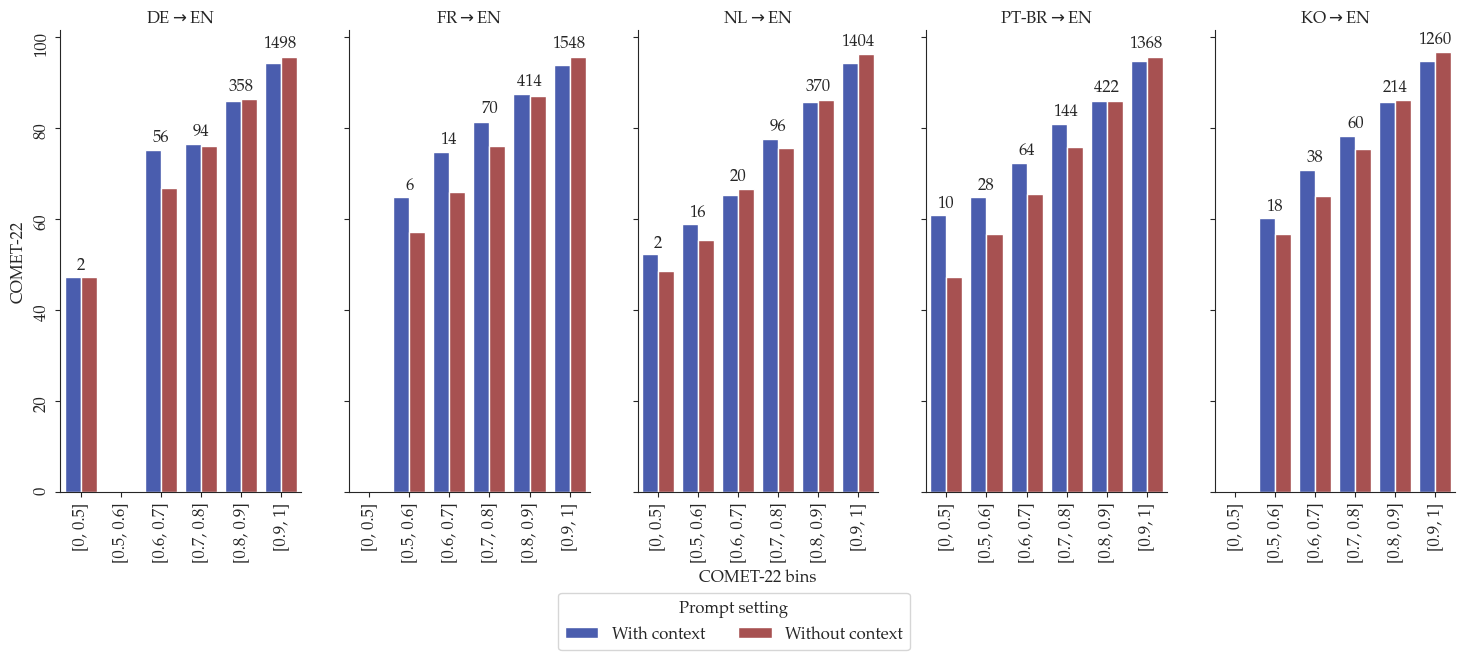

In [9]:
plot_df = df.copy()

# Manually order the COMET-22 bins
order = [
    "[0, 0.5]",
    "[0.5, 0.6]",
    "[0.6, 0.7]",
    "[0.7, 0.8]",
    "[0.8, 0.9]",
    "[0.9, 1]",
]

# Convert both DataFrames into long format
full_plot_df = pd.melt(
    plot_df,
    id_vars=["lp", "comet_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
full_plot_df["comet"] = 100 * full_plot_df["comet"]

cmap = sns.color_palette(["#3953BF", "#b54343"])

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for lp, ax in zip(
    ["de-en", "fr-en", "nl-en", "pt-br-en", "ko-en"], [ax1, ax2, ax3, ax4, ax5]
):
    xx = lp.split("-")[0] if lp != "pt-br-en" else "pt-br"
    plot_df = full_plot_df[full_plot_df["lp"] == lp]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=plot_df,
        x="comet_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        order=order,
        legend=True if ax == ax1 else False,
    )

    # Calculate counts and mean heights for en-xx
    plot_df_counts = plot_df.groupby("comet_bin").size()
    plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()

    # Add counts to the en-xx plot
    for i, bin_label in enumerate(order):
        if bin_label in plot_df_counts.index:
            count = plot_df_counts[bin_label]
            max_mean_height = plot_df_means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height + 0.01 * max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )
    sns.despine(ax=ax, right=True, left=False)

    # Set x-tick labels and axis labels
    ax.set_xticklabels(order)
    if ax == ax1:
        ax.set_ylabel("COMET-22", fontsize=12)
    else:
        ax.set_ylabel("")
    if ax == ax3:
        ax.set_xlabel("COMET-22 bins", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
        rotation=90,
    )
    ax.set_title(rf"{xx.upper()}$\rightarrow$EN", fontsize=12)
# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(2.8, -0.2),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# ax.grid(axis="y")
plt.savefig("plots/comet_bins_context_lps_xx_en.pdf", bbox_inches="tight")
plt.show()

# Muda barplot

In [10]:
df["has_tags"] = df["tags"].apply(lambda x: "Yes" if x != "[]" else "No")
df["has_tags"].value_counts()

has_tags
No     8486
Yes    1683
Name: count, dtype: int64

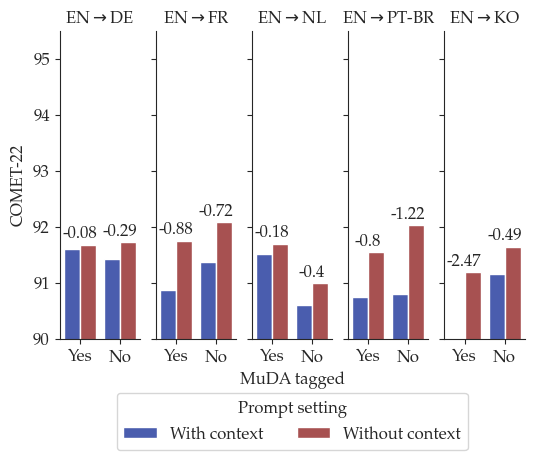

In [24]:
# muda applies only to en-xx LPs
plot_df = df[df["lp"].str.startswith("en-")]

# Manually order tags
order = [
    "Yes",
    "No",
]
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(6, 4), sharey=True)

dfs_by_lp = {}
for lp, ax in zip(
    ["en-de", "en-fr", "en-nl", "en-pt-br", "en-ko"], [ax1, ax2, ax3, ax4, ax5]
):
    if lp != "en-pt-br":
        xx = lp.split("-")[1].upper()
    else:
        xx = "PT-BR"
    temp_df = plot_df[plot_df["lp"] == lp]
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=["has_tags"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x="has_tags",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax3 else False,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    ax.set_title(rf"EN$\rightarrow${xx}", fontsize=12)
    # ax.set_xticklabels(order)
    if ax == ax3:
        ax.set_xlabel("MuDA tagged", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.set_ylim(90, 95.5)
    # Calculate counts and mean heights for en-xx
    # calculate difference between the two bars
    diffs = {}
    for o in order:
        temp_df_diff = (
            temp_df[
                (temp_df["model"] == f"{model}-w-context-comet")
                & (temp_df["has_tags"] == o)
            ]["comet"].mean()
            - temp_df[
                (temp_df["model"] == f"{model}-wo-context-comet")
                & (temp_df["has_tags"] == o)
            ]["comet"].mean()
        )
        diffs[o] = round(temp_df_diff, 2)
    temp_df_means = temp_df.groupby(["has_tags", "model"])["comet"].mean().unstack()
    # Add counts to plot
    for i, bin_label in enumerate(order):
        if bin_label in order:
            diff = diffs[bin_label]
            max_mean_height = temp_df_means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height + 0.03,
                f"{diff}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# plt.savefig("plots/muda_bins_context.pdf", bbox_inches="tight")

plt.show()

# PCXMI bins

In [12]:
from tower_eval.utils import read_lines

df["pcxmi_ref"] = 0.0
df["pcxmi_hyp"] = 0.0

for lp in [
    "en-de",
    "en-fr",
    "en-nl",
    "en-pt-br",
    "en-ko",
    "de-en",
    "fr-en",
    "nl-en",
    "pt-br-en",
    "ko-en",
]:
    for part in ["hyp", "ref"]:
        log_probs_cxt = [
            float(l)
            for l in read_lines(
                f"/mnt/data/jpombal/wmt24-chat-translation/pcxmi/full_context/mt/wmt24_chat_test_blind.{lp}/TowerInstruct-7B-v0.2/mean_log_probs_{part}.txt"
            )
        ]
        log_probs_no_cxt = [
            float(l)
            for l in read_lines(
                f"/mnt/data/jpombal/wmt24-chat-translation/pcxmi/no_context/mt/wmt24_chat_test_blind.{lp}/TowerInstruct-7B-v0.2/mean_log_probs_{part}.txt"
            )
        ]
        pcxmi = [w - wo for w, wo in zip(log_probs_cxt, log_probs_no_cxt)]
        df.loc[(df["lp"] == lp), f"pcxmi_{part}"] = pcxmi

### en-xx, ref

/mnt/data/jpombal/tmp/ipykernel_1637216/3505604644.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/3505604644.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/3505604644.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

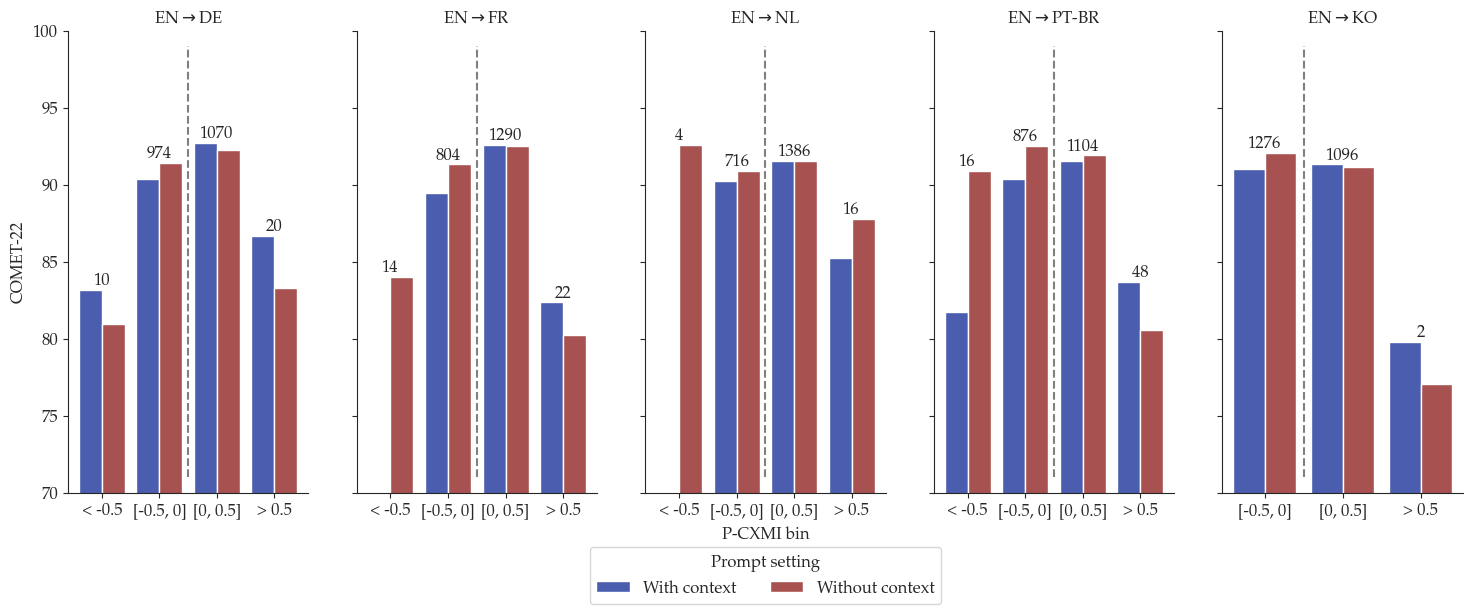

In [13]:
# muda applies only to en-xx LPs
part = "ref"
plot_df = df[df["lp"].str.startswith("en-")]
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

order = [
    "< -0.5",
    "[-0.5, 0]",
    "[0, 0.5]",
    "> 0.5",
]

dfs_by_lp = {}
for lp, ax in zip(
    ["en-de", "en-fr", "en-nl", "en-pt-br", "en-ko"], [ax1, ax2, ax3, ax4, ax5]
):
    if lp != "en-pt-br":
        xx = lp.split("-")[1].upper()
    else:
        xx = "PT-BR"
    temp_df = plot_df[plot_df["lp"] == lp]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.5, 0, 0.5, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax3 else False,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    ax.set_title(rf"EN$\rightarrow${xx}", fontsize=12)
    # ax.set_xticklabels(order)
    if ax == ax3:
        ax.set_xlabel("P-CXMI bin", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for xx-en
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

# ax1.annotate(
#     "Improvement\nin quality\nfrom adding\ncontext.",
#     xy=(0.75, 93.1),  # point to which the arrow will point
#     xytext=(-0.4, 94),  # position of the text
#     arrowprops=dict(
#         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
#     ),
#     fontsize=10,
#     color="black",
#     ha="left",
# )

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
plt.savefig("plots/pcxmi_bins_context_ref_lps_en_xx.pdf", bbox_inches="tight")

plt.show()

### xx-en

/mnt/data/jpombal/tmp/ipykernel_1637216/4236950098.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/4236950098.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/4236950098.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

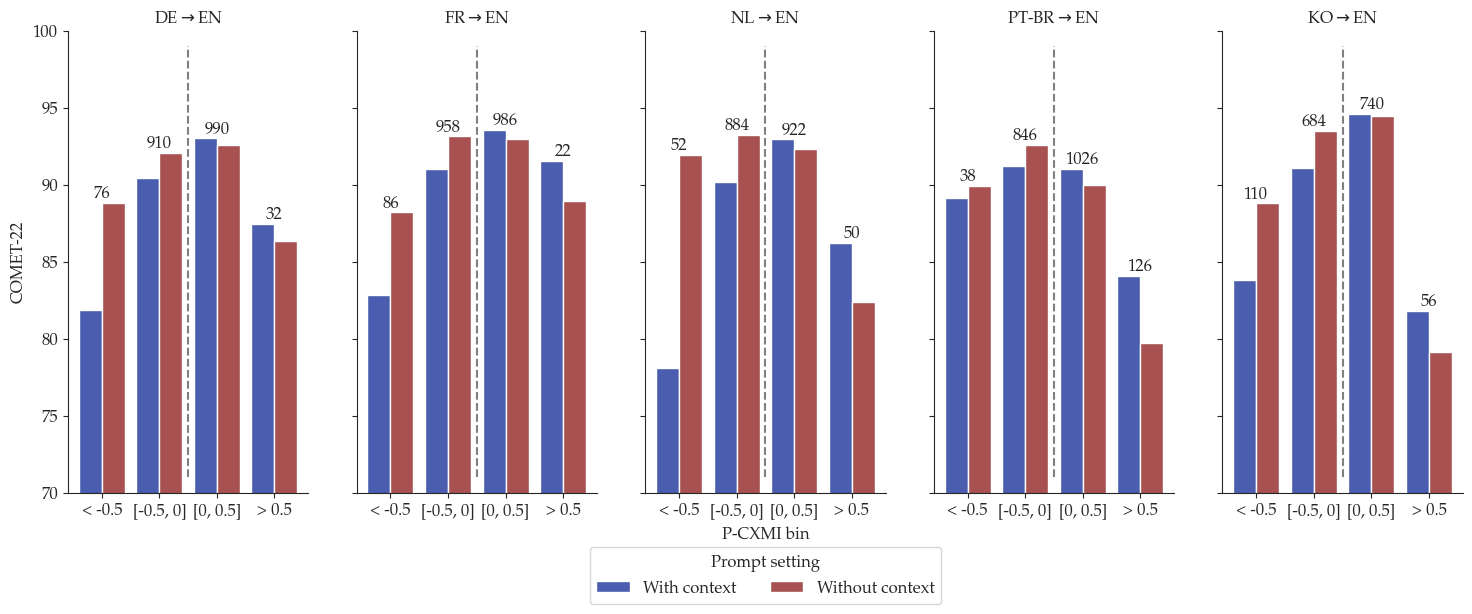

In [14]:
# muda applies only to en-xx LPs
part = "ref"
plot_df = df[df["lp"].str.endswith("-en")]
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

order = [
    "< -0.5",
    "[-0.5, 0]",
    "[0, 0.5]",
    "> 0.5",
]

dfs_by_lp = {}
for lp, ax in zip(
    ["de-en", "fr-en", "nl-en", "pt-br-en", "ko-en"], [ax1, ax2, ax3, ax4, ax5]
):
    if lp != "pt-br-en":
        xx = lp.split("-")[0].upper()
    else:
        xx = "PT-BR"
    temp_df = plot_df[plot_df["lp"] == lp]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.5, 0, 0.5, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax3 else False,
        order=order,
    )
    ax.set_title(rf"{xx}$\rightarrow$EN", fontsize=12)
    sns.despine(ax=ax, right=True, left=False)
    # ax.set_xticklabels(order)
    if ax == ax3:
        ax.set_xlabel("P-CXMI bin", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for xx-en
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

# ax1.annotate(
#     "Improvement\nin quality\nfrom adding\ncontext.",
#     xy=(0.75, 93.1),  # point to which the arrow will point
#     xytext=(-0.4, 94),  # position of the text
#     arrowprops=dict(
#         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
#     ),
#     fontsize=10,
#     color="black",
#     ha="left",
# )

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
plt.savefig("plots/pcxmi_bins_context_ref_lps_xx_en.pdf", bbox_inches="tight")

plt.show()

# aggregate language pairs

/mnt/data/jpombal/tmp/ipykernel_1637216/1384722104.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/1384722104.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/1384722104.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

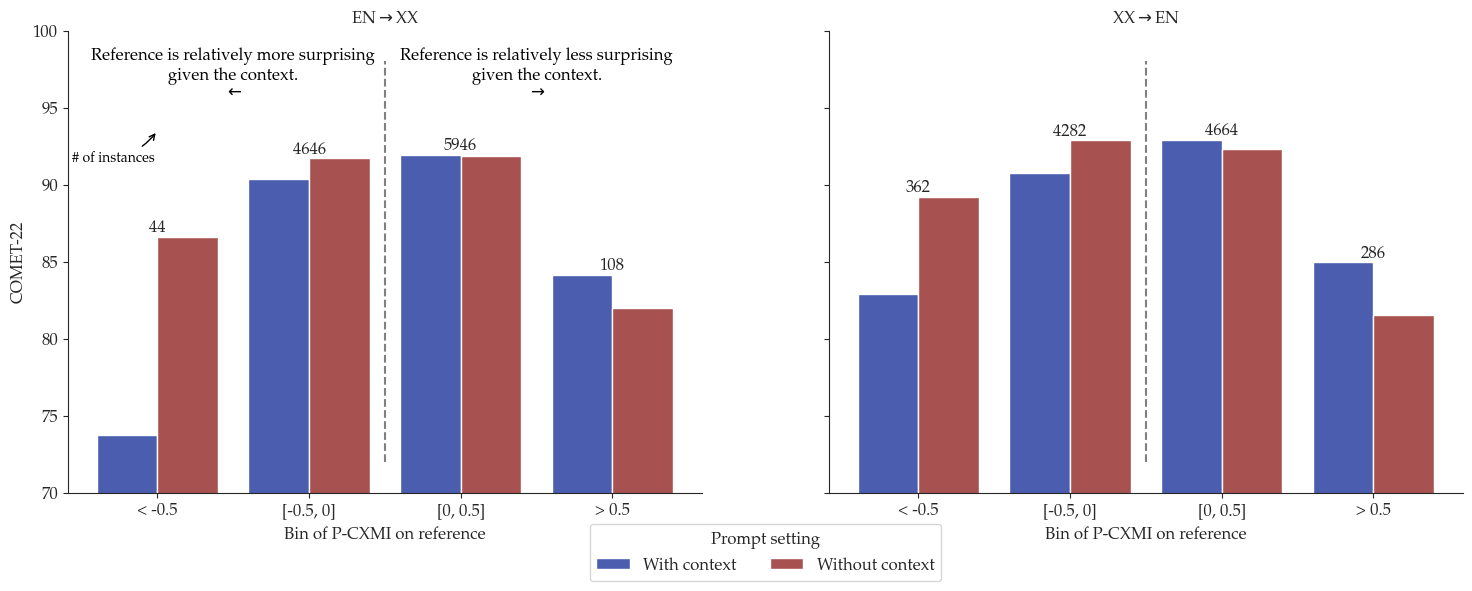

In [15]:
# muda applies only to en-xx LPs
part = "ref"
plot_df = df.copy()
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

order = [
    "< -0.5",
    "[-0.5, 0]",
    "[0, 0.5]",
    "> 0.5",
]

dfs_by_lp = {}
for lp, ax in zip([rf"EN$\rightarrow$XX", rf"XX$\rightarrow$EN"], [ax1, ax2]):
    if lp == rf"EN$\rightarrow$XX":
        temp_df = df[df["lp"].str.startswith("en-")]
    else:
        temp_df = df[df["lp"].str.endswith("-en")]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.5, 0, 0.5, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax1 else False,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    ax.set_title(lp, fontsize=12)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of P-CXMI on reference", fontsize=12)
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for en-xx
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

ax1.annotate(
    "Reference is relatively more surprising\ngiven the context.",
    xy=(0.5, 96.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\leftarrow$",
    xy=(0.5, 95.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax1.annotate(
    "Reference is relatively less surprising\ngiven the context.",
    xy=(2.5, 96.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\rightarrow$",
    xy=(2.5, 95.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(1.1, -0.05),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
ax1.annotate(
    "# of instances",
    xy=(0, 93.5),  # point to which the arrow will point
    xytext=(-0.29, 91.5),  # position of the text
    arrowprops=dict(
        arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    ),
    fontsize=10,
    color="black",
    ha="center",
)
# plt.savefig("plots/pcxmi_bins_context_ref.pdf", bbox_inches="tight")
plt.show()

# aggregate all lps

/mnt/data/jpombal/tmp/ipykernel_1637216/1495294945.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/1495294945.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()


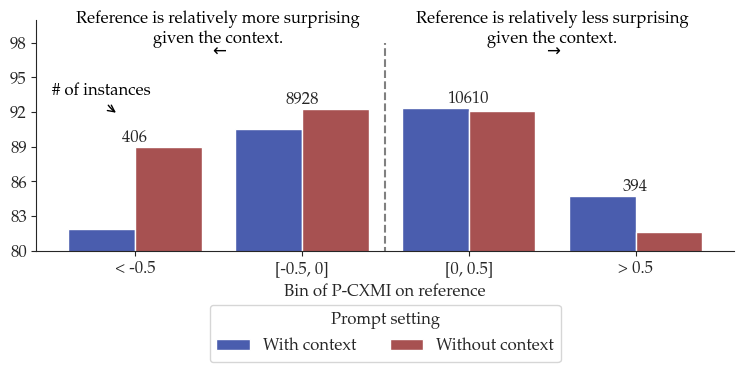

In [23]:
part = "ref"
plot_df = df.copy()
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, ax = plt.subplots(figsize=(9, 3))

order = [
    "< -0.5",
    "[-0.5, 0]",
    "[0, 0.5]",
    "> 0.5",
]
# cut in pcxmi bins
plot_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
    plot_df[f"pcxmi_{part}"],
    bins=[-float("inf"), -0.5, 0, 0.5, float("inf")],
    labels=order,
)
# Convert DataFrames into long format
plot_df = pd.melt(
    plot_df,
    id_vars=[f"pcxmi_{part}_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
plot_df["comet"] = 100 * plot_df["comet"]
# Plot for en-xx language pairs
sns.barplot(
    ax=ax,
    data=plot_df,
    x=f"pcxmi_{part}_bin",
    y="comet",
    hue="model",
    errorbar=None,
    hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
    palette=cmap,
    legend=True,
    order=order,
)
sns.despine(ax=ax, right=True, left=False)
# ax.set_xticklabels(order)
ax.set_xlabel("Bin of P-CXMI on reference", fontsize=12)
ax.set_ylabel("COMET-22", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)
if ax != ax1:
    ax.set_ylabel("")
ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
ax.set_ylim(85, 100)
# Calculate counts and mean heights for en-xx
counts = plot_df.groupby(f"pcxmi_{part}_bin").size()
means = plot_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
# Add counts to the xx-en plot
for i, bin_label in enumerate(order):
    if bin_label in counts.index:
        count = counts[bin_label]
        max_mean_height = means.loc[bin_label].max()
        ax.text(
            i,
            max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=12,
        )

ax.annotate(
    "Reference is relatively more surprising\ngiven the context.",
    xy=(0.5, 98),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax.annotate(
    r"$\leftarrow$",
    xy=(0.5, 97),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax.annotate(
    "Reference is relatively less surprising\ngiven the context.",
    xy=(2.5, 98),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax.annotate(
    r"$\rightarrow$",
    xy=(2.5, 97),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.2),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
ax.set_yticks(range(80, 101, 3))
ax.annotate(
    "# of instances",
    xy=(-0.1, 91.8),  # point to which the arrow will point
    xytext=(-0.2, 93.5),  # position of the text
    arrowprops=dict(
        arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    ),
    fontsize=12,
    color="black",
    ha="center",
)
# plt.savefig("plots/pcxmi_bins_context_ref_agg.pdf", bbox_inches="tight")
plt.show()

/mnt/data/jpombal/tmp/ipykernel_1637216/2320850862.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/2320850862.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/2320850862.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

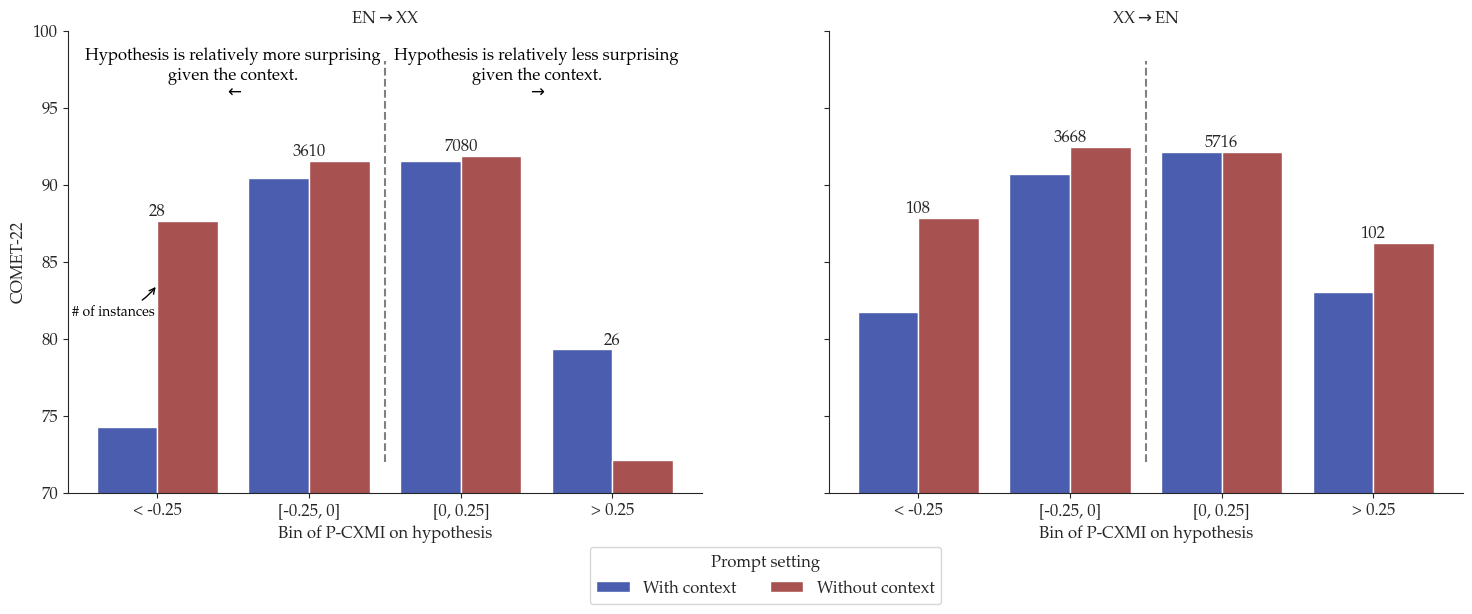

In [17]:
# muda applies only to en-xx LPs
part = "hyp"
plot_df = df.copy()
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

order = [
    "< -0.25",
    "[-0.25, 0]",
    "[0, 0.25]",
    "> 0.25",
]

dfs_by_lp = {}
for lp, ax in zip([rf"EN$\rightarrow$XX", rf"XX$\rightarrow$EN"], [ax1, ax2]):
    if lp == rf"EN$\rightarrow$XX":
        temp_df = df[df["lp"].str.startswith("en-")]
    else:
        temp_df = df[df["lp"].str.endswith("-en")]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.25, 0, 0.25, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax1 else False,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    ax.set_title(lp, fontsize=12)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of P-CXMI on hypothesis", fontsize=12)
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for xx-en
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

ax1.annotate(
    "Hypothesis is relatively more surprising\ngiven the context.",
    xy=(0.5, 96.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\leftarrow$",
    xy=(0.5, 95.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax1.annotate(
    "Hypothesis is relatively less surprising\ngiven the context.",
    xy=(2.5, 96.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\rightarrow$",
    xy=(2.5, 95.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(1.1, -0.1),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
ax1.annotate(
    "# of instances",
    xy=(0, 83.5),  # point to which the arrow will point
    xytext=(-0.29, 81.5),  # position of the text
    arrowprops=dict(
        arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    ),
    fontsize=10,
    color="black",
    ha="center",
)
# plt.savefig("plots/pcxmi_bins_context_hyp.pdf", bbox_inches="tight")

plt.show()

# aggregate all LPs

/mnt/data/jpombal/tmp/ipykernel_1637216/3519210304.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/3519210304.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()


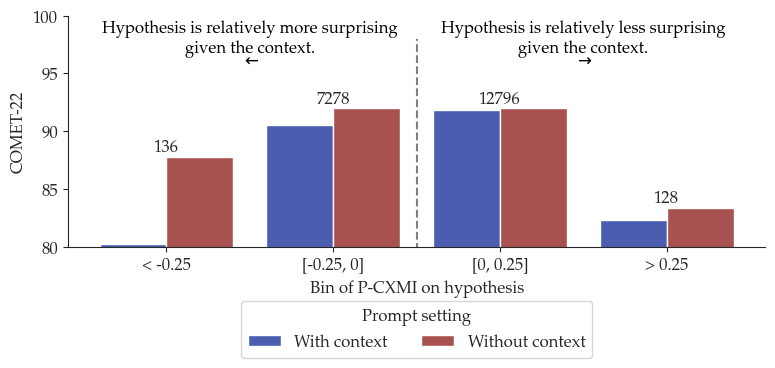

In [25]:
# muda applies only to en-xx LPs
part = "hyp"
plot_df = df.copy()
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, ax = plt.subplots(figsize=(9, 3), sharey=True)

order = [
    "< -0.25",
    "[-0.25, 0]",
    "[0, 0.25]",
    "> 0.25",
]
# cut in pcxmi bins
plot_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
    plot_df[f"pcxmi_{part}"],
    bins=[-float("inf"), -0.25, 0, 0.25, float("inf")],
    labels=order,
)
# Convert DataFrames into long format
plot_df = pd.melt(
    plot_df,
    id_vars=[f"pcxmi_{part}_bin"],
    value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
    var_name="model",
    value_name="comet",
)
plot_df["comet"] = 100 * plot_df["comet"]
# Plot for en-xx language pairs
sns.barplot(
    ax=ax,
    data=plot_df,
    x=f"pcxmi_{part}_bin",
    y="comet",
    hue="model",
    errorbar=None,
    hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
    palette=cmap,
    legend=True,
    order=order,
)
sns.despine(ax=ax, right=True, left=False)
# ax.set_xticklabels(order)
ax.set_xlabel("Bin of P-CXMI on hypothesis", fontsize=12)
ax.set_ylabel("COMET-22", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
ax.set_ylim(80, 100)
# Calculate counts and mean heights for xx-en
counts = plot_df.groupby(f"pcxmi_{part}_bin").size()
means = plot_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
# Add counts to the xx-en plot
for i, bin_label in enumerate(order):
    if bin_label in counts.index:
        count = counts[bin_label]
        max_mean_height = means.loc[bin_label].max()
        ax.text(
            i,
            max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=12,
        )

ax.annotate(
    "Hypothesis is relatively more surprising\ngiven the context.",
    xy=(0.5, 96.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax.annotate(
    r"$\leftarrow$",
    xy=(0.5, 95.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax.annotate(
    "Hypothesis is relatively less surprising\ngiven the context.",
    xy=(2.5, 96.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)
ax.annotate(
    r"$\rightarrow$",
    xy=(2.5, 95.8),  # position of the text
    fontsize=12,
    color="black",
    ha="center",
)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.2),
    fontsize=12,
    loc="upper center",
    ncol=2,
)

# plt.savefig("plots/pcxmi_bins_context_hyp_agg.pdf", bbox_inches="tight")

plt.show()

# more bins

/mnt/data/jpombal/tmp/ipykernel_1637216/2168741003.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(


/mnt/data/jpombal/tmp/ipykernel_1637216/2168741003.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/2168741003.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1637216/2168741003.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

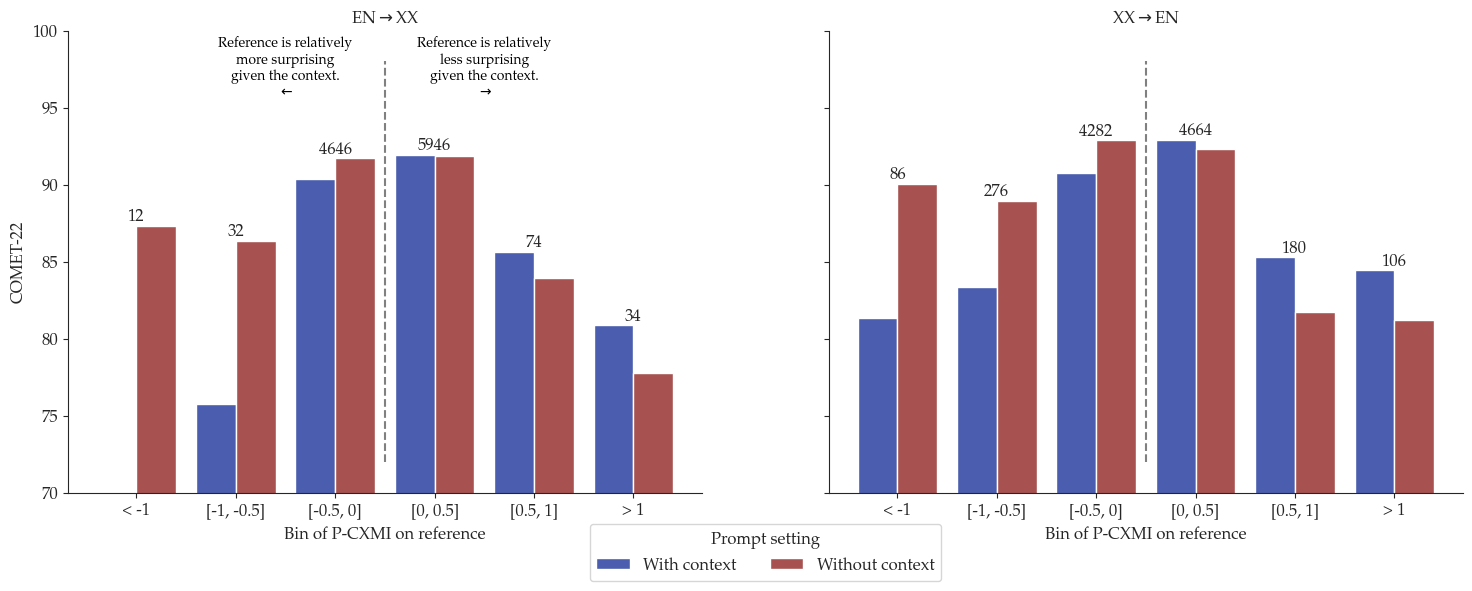

In [19]:
# muda applies only to en-xx LPs
part = "ref"
plot_df = df.copy()
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

order = [
    "< -1",
    "[-1, -0.5]",
    "[-0.5, 0]",
    "[0, 0.5]",
    "[0.5, 1]",
    "> 1",
]

dfs_by_lp = {}
for lp, ax in zip([rf"EN$\rightarrow$XX", rf"XX$\rightarrow$EN"], [ax1, ax2]):
    if lp == rf"EN$\rightarrow$XX":
        temp_df = df[df["lp"].str.startswith("en-")]
    else:
        temp_df = df[df["lp"].str.endswith("-en")]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -1.0, -0.5, 0, 0.5, 1.0, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax1 else False,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    ax.set_title(lp, fontsize=12)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of P-CXMI on reference", fontsize=12)
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[2.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for en-xx
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

ax1.annotate(
    "Reference is relatively\nmore surprising\ngiven the context.",
    xy=(1.5, 96.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\leftarrow$",
    xy=(1.5, 95.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)
ax1.annotate(
    "Reference is relatively\nless surprising\ngiven the context.",
    xy=(3.5, 96.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\rightarrow$",
    xy=(3.5, 95.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(1.1, -0.05),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# plt.savefig("plots/muda_bins_context.pdf", bbox_inches="tight")
plt.show()

/mnt/data/jpombal/tmp/ipykernel_1637216/4117108125.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/4117108125.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/4117108125.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

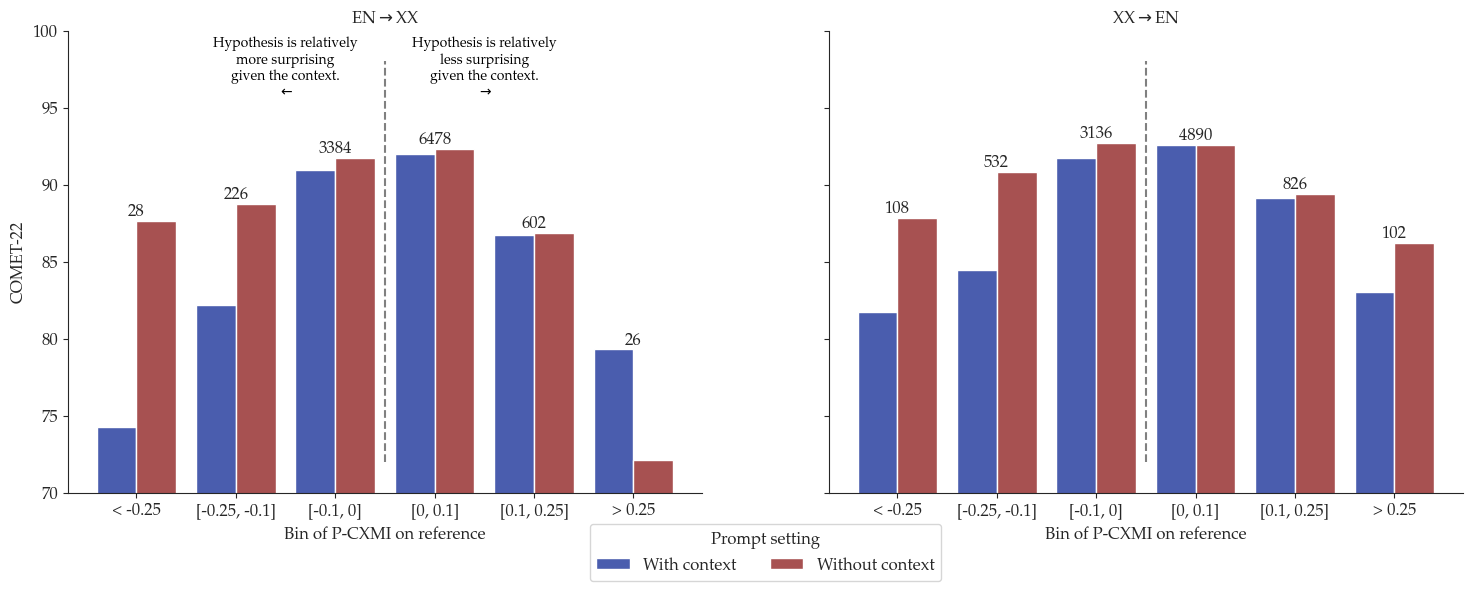

In [20]:
# muda applies only to en-xx LPs
part = "hyp"
plot_df = df.copy()
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

order = [
    "< -0.25",
    "[-0.25, -0.1]",
    "[-0.1, 0]",
    "[0, 0.1]",
    "[0.1, 0.25]",
    "> 0.25",
]

dfs_by_lp = {}
for lp, ax in zip([rf"EN$\rightarrow$XX", rf"XX$\rightarrow$EN"], [ax1, ax2]):
    if lp == rf"EN$\rightarrow$XX":
        temp_df = df[df["lp"].str.startswith("en-")]
    else:
        temp_df = df[df["lp"].str.endswith("-en")]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.25, -0.1, 0, 0.1, 0.25, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax1 else False,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    ax.set_title(lp, fontsize=12)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of P-CXMI on reference", fontsize=12)
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[2.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for en-xx
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

ax1.annotate(
    "Hypothesis is relatively\nmore surprising\ngiven the context.",
    xy=(1.5, 96.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\leftarrow$",
    xy=(1.5, 95.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)
ax1.annotate(
    "Hypothesis is relatively\nless surprising\ngiven the context.",
    xy=(3.5, 96.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)
ax1.annotate(
    r"$\rightarrow$",
    xy=(3.5, 95.8),  # position of the text
    fontsize=10,
    color="black",
    ha="center",
)

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(1.1, -0.05),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
# plt.savefig("plots/muda_bins_context.pdf", bbox_inches="tight")
plt.show()

### by lp

/mnt/data/jpombal/tmp/ipykernel_1637216/3116644447.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/3116644447.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/3116644447.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

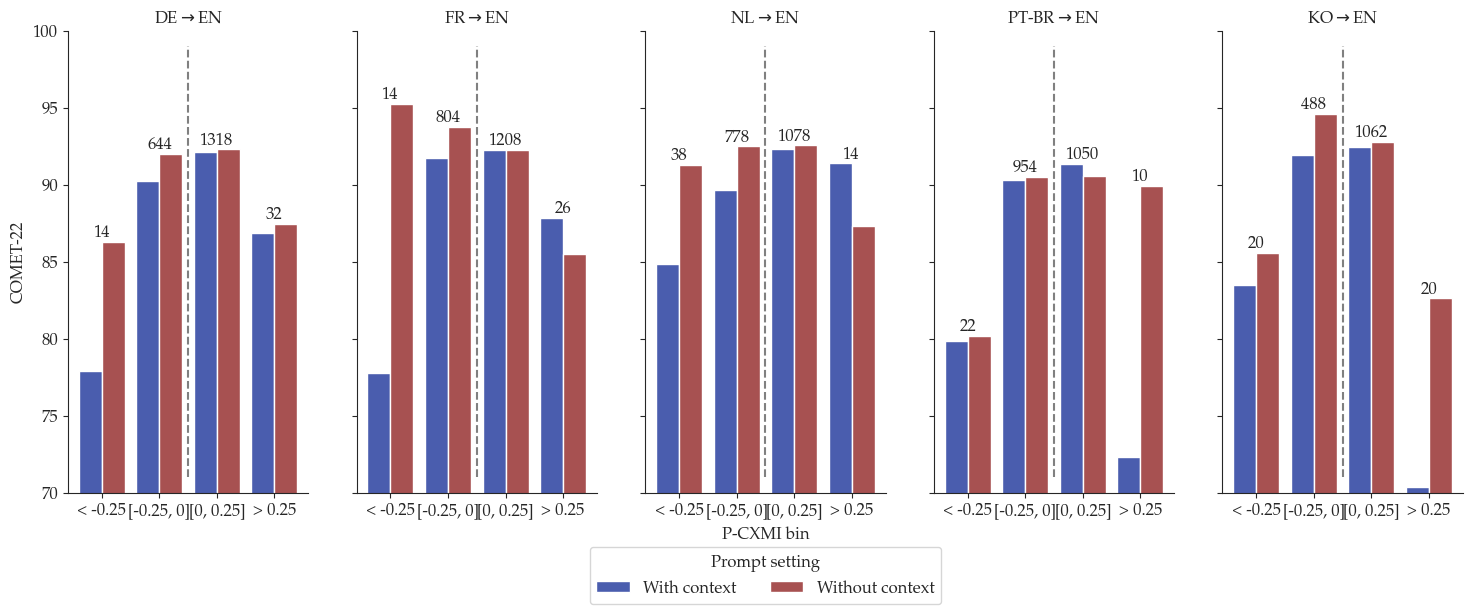

In [21]:
# muda applies only to en-xx LPs
part = "hyp"
plot_df = df[df["lp"].str.endswith("-en")]
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

order = [
    "< -0.25",
    "[-0.25, 0]",
    "[0, 0.25]",
    "> 0.25",
]

dfs_by_lp = {}
for lp, ax in zip(
    ["de-en", "fr-en", "nl-en", "pt-br-en", "ko-en"], [ax1, ax2, ax3, ax4, ax5]
):
    if lp != "pt-br-en":
        xx = lp.split("-")[0].upper()
    else:
        xx = "PT-BR"
    temp_df = plot_df[plot_df["lp"] == lp]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.25, 0, 0.25, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax3 else False,
        order=order,
    )
    ax.set_title(rf"{xx}$\rightarrow$EN", fontsize=12)
    sns.despine(ax=ax, right=True, left=False)
    # ax.set_xticklabels(order)
    if ax == ax3:
        ax.set_xlabel("P-CXMI bin", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for xx-en
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

# ax1.annotate(
#     "Improvement\nin quality\nfrom adding\ncontext.",
#     xy=(0.75, 93.1),  # point to which the arrow will point
#     xytext=(-0.4, 94),  # position of the text
#     arrowprops=dict(
#         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
#     ),
#     fontsize=10,
#     color="black",
#     ha="left",
# )

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
plt.savefig("plots/pcxmi_bins_context_hyp_lps_xx_en.pdf", bbox_inches="tight")

plt.show()

/mnt/data/jpombal/tmp/ipykernel_1637216/3952788326.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1637216/3952788326.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1637216/3952788326.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

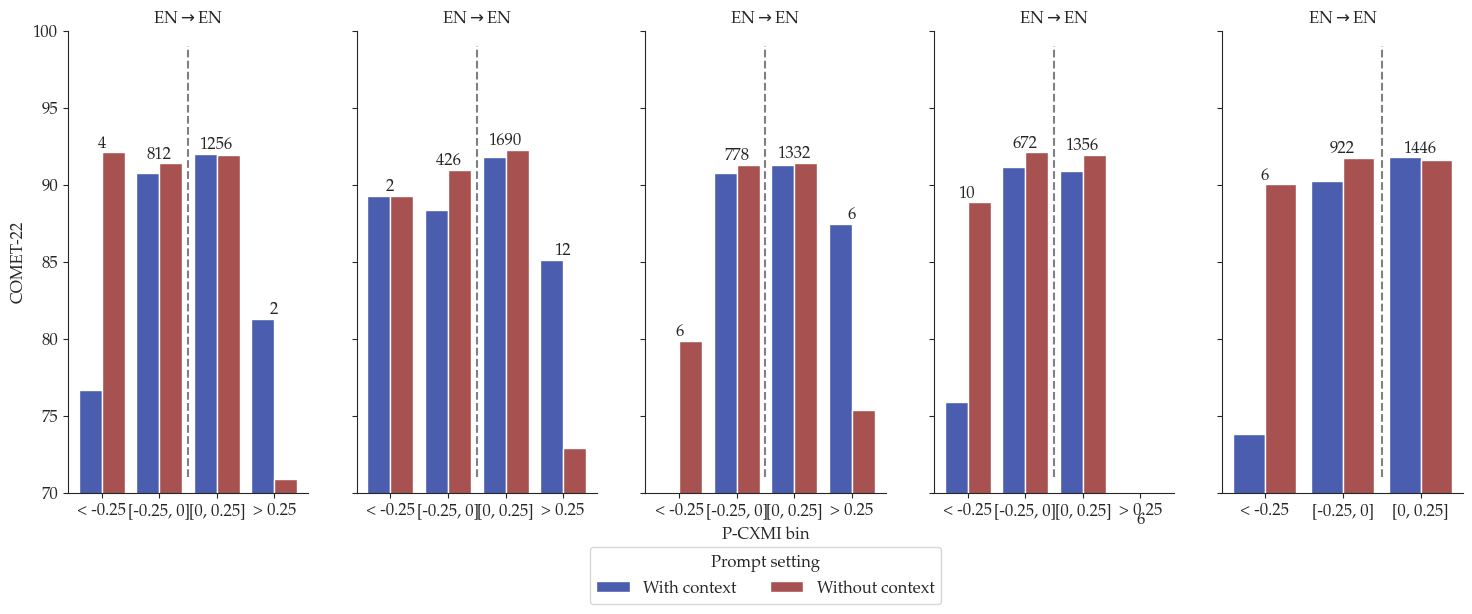

In [22]:
# muda applies only to en-xx LPs
part = "hyp"
plot_df = df[df["lp"].str.startswith("en-")]
cmap = sns.color_palette(["#3953BF", "#b54343"])

# create
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

order = [
    "< -0.25",
    "[-0.25, 0]",
    "[0, 0.25]",
    "> 0.25",
]

dfs_by_lp = {}
for lp, ax in zip(
    ["en-de", "en-fr", "en-nl", "en-pt-br", "en-ko"], [ax1, ax2, ax3, ax4, ax5]
):
    if lp != "pt-br-en":
        xx = lp.split("-")[0].upper()
    else:
        xx = "PT-BR"
    temp_df = plot_df[plot_df["lp"] == lp]
    # cut in pcxmi bins
    temp_df.loc[:, f"pcxmi_{part}_bin"] = pd.cut(
        temp_df[f"pcxmi_{part}"],
        bins=[-float("inf"), -0.25, 0, 0.25, float("inf")],
        labels=order,
    )
    # Convert DataFrames into long format
    temp_df = pd.melt(
        temp_df,
        id_vars=[f"pcxmi_{part}_bin"],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    temp_df["comet"] = 100 * temp_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=temp_df,
        x=f"pcxmi_{part}_bin",
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True if ax == ax3 else False,
        order=order,
    )
    ax.set_title(rf"{xx}$\rightarrow$EN", fontsize=12)
    sns.despine(ax=ax, right=True, left=False)
    # ax.set_xticklabels(order)
    if ax == ax3:
        ax.set_xlabel("P-CXMI bin", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.set_ylabel("COMET-22", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    if ax != ax1:
        ax.set_ylabel("")
    ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
    ax.set_ylim(70, 100)
    # Calculate counts and mean heights for xx-en
    counts = temp_df.groupby(f"pcxmi_{part}_bin").size()
    means = temp_df.groupby([f"pcxmi_{part}_bin", "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=12,
            )

# ax1.annotate(
#     "Improvement\nin quality\nfrom adding\ncontext.",
#     xy=(0.75, 93.1),  # point to which the arrow will point
#     xytext=(-0.4, 94),  # position of the text
#     arrowprops=dict(
#         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
#     ),
#     fontsize=10,
#     color="black",
#     ha="left",
# )

# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(
    handles=handles,
    labels=["With context", "Without context"],
    title="Prompt setting",
    title_fontsize=12,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=12,
    loc="upper center",
    ncol=2,
)
plt.savefig("plots/pcxmi_bins_context_hyp_lps_en_xx.pdf", bbox_inches="tight")

plt.show()